## 딥러닝에 사용되는 도구

In [1]:
my_list = [10, 'hello', 20]
print(my_list)
print(my_list[1])

[10, 'hello', 20]
hello


In [2]:
my_list2 =[[10, 20,30], [40, 50, 60]]
print(my_list2)
print([my_list2[0]])
print([my_list2[0][2]])

[[10, 20, 30], [40, 50, 60]]
[[10, 20, 30]]
[30]


In [1]:
import numpy as np
print(np.__version__)

2.4.4


In [4]:
arr1 = np.array([[10, 20, 30], [40, 50, 60]])
print(arr1)
type(arr1)

[[10 20 30]
 [40 50 60]]


numpy.ndarray

In [5]:
arr1[0]

array([10, 20, 30])

In [6]:
arr1[0][1]

np.int64(20)

In [7]:
np.sum(arr1)

np.int64(210)

In [2]:
import matplotlib.pyplot as plt

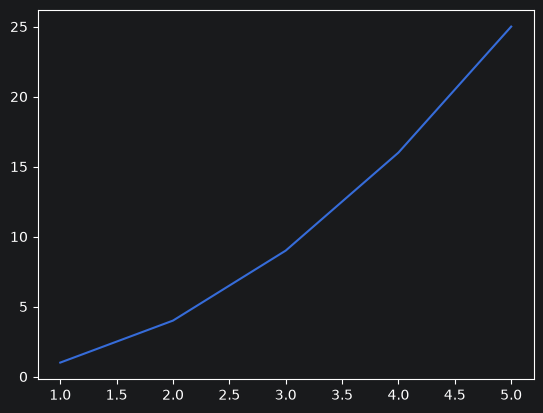

In [9]:
plt.plot([1, 2, 3, 4, 5], [1, 4, 9, 16, 25]) # x 좌표와 y 좌표를 파이썬 리스트로 전달한다.
plt.show()

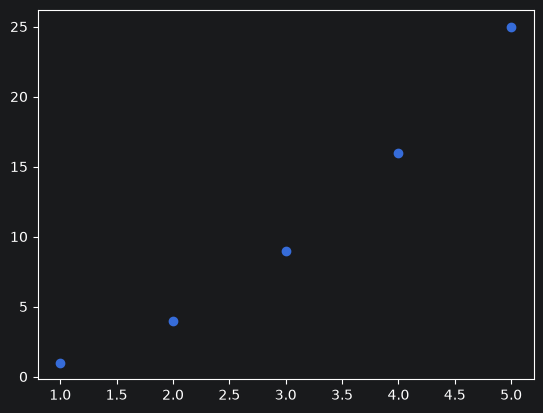

In [10]:
plt.scatter([1, 2, 3, 4, 5], [1, 4, 9, 16, 25])

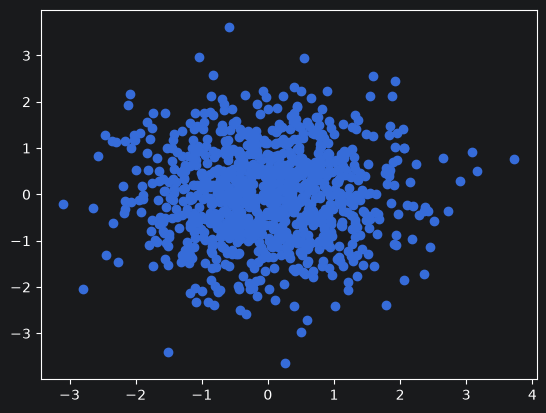

In [11]:
x = np.random.randn(1000) # 표준정규분포를 따르는 난수를 1000개 만든다
y = np.random.randn(1000)
plt.scatter(x, y)
plt.show()

# 머신러닝 기초 다지기

## 1. 선형회귀
목표: 당뇨병 환자의 1년 후 병의 진전된 정도를 예측하는 모델을 만들어보자.

사이킷런, 케라스에서 머신러닝을 위한 데이터셋을 제공한다.

사이킷런의 당뇨병 환자 데이터셋을 사용한다.

In [3]:
from sklearn.datasets import load_diabetes
diabetes = load_diabetes()
print(diabetes.data.shape, diabetes.target.shape)

(442, 10) (442,)


In [16]:
diabetes.data[0:3]

array([[ 0.03807591,  0.05068012,  0.06169621,  0.02187239, -0.0442235 ,
        -0.03482076, -0.04340085, -0.00259226,  0.01990749, -0.01764613],
       [-0.00188202, -0.04464164, -0.05147406, -0.02632753, -0.00844872,
        -0.01916334,  0.07441156, -0.03949338, -0.06833155, -0.09220405],
       [ 0.08529891,  0.05068012,  0.04445121, -0.00567042, -0.04559945,
        -0.03419447, -0.03235593, -0.00259226,  0.00286131, -0.02593034]])

In [17]:
diabetes.target[0:3]

array([151.,  75., 141.])

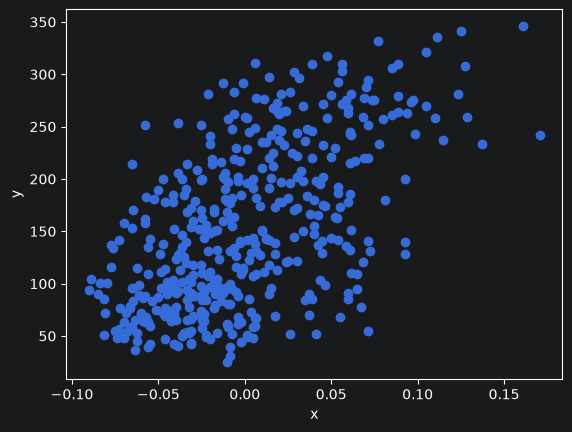

In [18]:
plt.scatter(diabetes.data[:, 2], diabetes.target)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [6]:
x = diabetes.data[:, 2]
y = diabetes.target
x_sample = x[99:109]
print(x_sample, x_sample.shape)

[-0.06440781  0.01750591 -0.04500719  0.02828403  0.04121778  0.06492964
 -0.03207344 -0.07626374  0.04984027  0.04552903] (10,)


## 2. 경사 하강법

In [40]:
# 1. w, b 초기화
w =1.0
b = 1.0

In [41]:
#훈련 데이터 첫번째 샘플로 예측값 구하기
y_hat = x[0] * w + b
print(y_hat) # 예측값

1.0616962065186832


In [42]:
print(y[0]) # 실제값

151.0


In [43]:
# 가중치 변화 주기
w_inc = w + 0.1
y_hat_inc = x[0] * w_inc + b
print(y_hat_inc)

1.0678658271705517


In [44]:
# 가중치 변화율 구하기
w_rate = (y_hat_inc - y_hat) / (w_inc - w)
print(w_rate)

0.06169620651868429


In [45]:
w_new = w + w_rate
print(w_new)

1.0616962065186843


In [46]:
# 절편 변화 주기
b_inc = b + 0.1
y_hat_inc = x[0] * w + b_inc
print(y_hat_inc)

1.1616962065186833


In [47]:
# 절편 변화율
b_rate = (y_hat_inc - y_hat) / (b_inc - b)
print(b_rate)

1.0


In [48]:
b_new = b + b_rate
print(b_new)

2.0


### 오차 역전파(Backpropagation) 구하기

예측값(y_hat)과 실제값(y)의 차이를 이용해 w와 b를 업데이트한다.

In [60]:
# 1. 오차와 변화율을 곱해 가중치 업데이트 시키기
err = y[0] -y_hat
w_new = w + w_rate * err # 가중치 업데이트
b_new = b + b_rate * err # 절편 업데이트
print(w_new, b_new)

911.1983904449359 156.2427820067777


In [61]:
y_hat = x[1] * w_new + b_new
err = y[1] - y_hat
w_rate = x[1]
w_new = w_new + w_rate * err
b_new = b_new + b_rate * err
print(w_new, b_new)

912.9659942788517 121.90308175045922


In [62]:
for x_i, y_i in zip(x, y):
    y_hat = x_i * w + b
    err = y_i - y_hat
    w_rate = x_i
    w = w + w_rate * err
    # b = b + b_rate * err
    b = b + 1 * err
print(w, b)

913.5973364346786 123.39414383177173


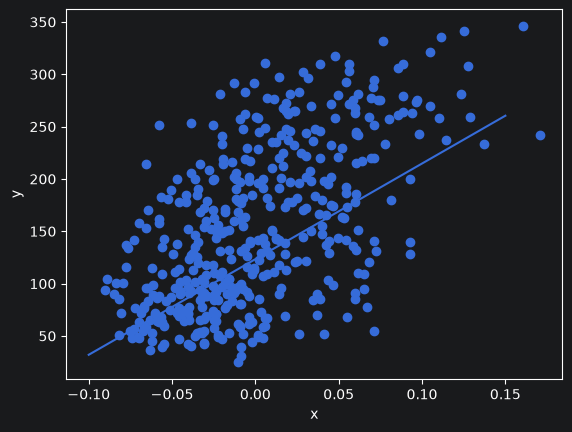

In [63]:
plt.scatter(x, y)
pt1 = (-0.1, -0.1 * w + b)
pt2 = (0.15, 0.15 * w + b)
plt.plot([pt1[0], pt2[0]], [pt1[1], pt2[1]])
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [64]:
# 위의 과정을 100회 에포크 진행
for i in range(1, 100):
    for x_i, y_i in zip(x, y):
        y_hat = x_i * w + b
        err = y_i - y_hat
        w_rate = x_i
        w = w + w_rate * err
        b = b + 1 * err
print(w, b)

913.5973364346786 123.39414383177173


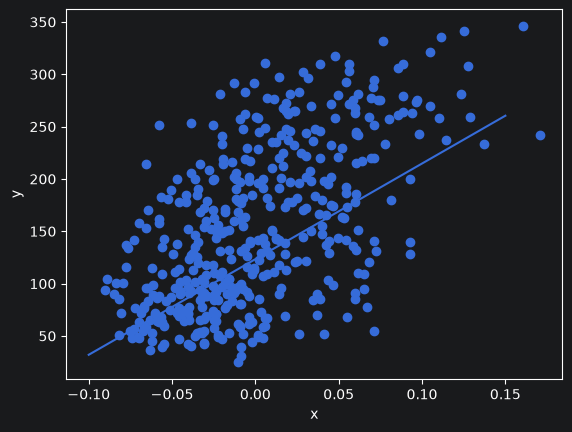

In [65]:
plt.scatter(x, y)
pt1 = (-0.1, -0.1 * w + b)
pt2 = (0.15, 0.15 * w + b)
plt.plot([pt1[0], pt2[0]], [pt1[1], pt2[1]])
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [66]:
# 모델로 예측하기
x_new = 0.18
y_pred = x_new * w + b
print(y_pred)

287.8416643900139


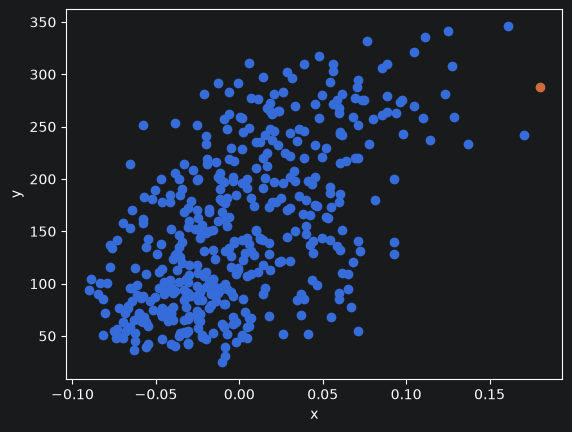

In [67]:
plt.scatter(x, y)
plt.scatter(x_new, y_pred)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

## 4. 뉴런 만들어보기

In [8]:
class Neuron:

    def __init__(self):
        self.w = 1.0 # 가중치 초기화
        self.b = 1.0 # 절편 초기화

    def forpass(self, x):
        y_hat = x * self.w + self.b
        return y_hat

    def backprop(self, x, err):
        w_grad = x * err
        b_grad = 1 * err
        return w_grad, b_grad

    def fit(self, x, y, epochs=100):
        for i in range(epochs):             # 에포크 만큼 반복한다.
            for x_i, y_i in zip(x, y):      # 모든 샘플에 대해 반복한다.
                y_hat = self.forpass(x_i)   # 정방향 계산
                err = -(y_i - y_hat)        # 오차 계산
                w_grad, b_grad = self.backprop(x_i, err)    # 역방향 계산
                self.w -= w_grad            # 가중치 업데이트
                self.b -= b_grad            # 절편 업데이트


In [9]:
neuron = Neuron()
neuron.fit(x, y)

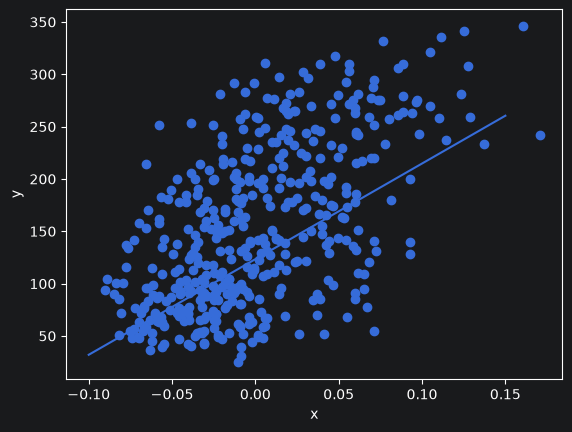

In [10]:
plt.scatter(x, y)
pt1 = (-0.1, -0.1 * neuron.w + neuron.b)
pt2 = (0.15, 0.15 * neuron.w + neuron.b)
plt.plot([pt1[0], pt2[0]], [pt1[1], pt2[1]])
plt.xlabel('x')
plt.ylabel('y')
plt.show()